In [33]:
%matplotlib widget
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

In [34]:


class ScrcpyCapture:
    def __init__(self, device="/dev/video2", rgb=True):
        self.rgb = rgb
        self.cap = cv2.VideoCapture(device, cv2.CAP_V4L2)
        if not self.cap.isOpened():
            raise RuntimeError(f"Could not open {device}")
        # Reduce latency:
        self.cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)

    def get_screen(self):
        ok, frame = self.cap.read()  # frame is np.ndarray (H, W, 3), dtype=uint8
        if not ok or frame is None:
            raise RuntimeError("Failed to read frame from v4l2 device")
        if self.rgb:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return frame

    def close(self):
        self.cap.release()

# Usage
# cap = ScrcpyCapture("/dev/video2", rgb=True)
# frame = cap.get_screen()  # np.ndarray
# cap.close()


In [35]:
cap = ScrcpyCapture("/dev/video2", rgb=True)
frame_with_cards = cap.get_screen()  # np.ndarray
cap.close()

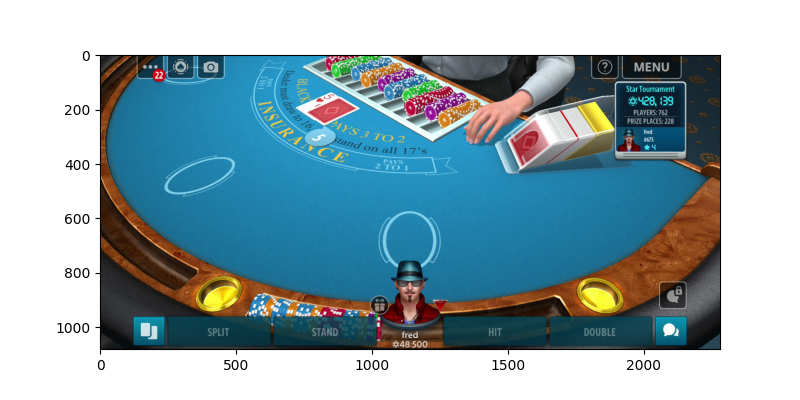

In [36]:
f, ax = plt.subplots(figsize=(8, 4))
ax.imshow(frame_with_cards)

In [ ]:
# plt.close()
# # Save the captured frame as a PNG (RGB preserved)
# import os


In [38]:
output_path = "frame.png"
plt.imsave(output_path, frame_with_cards)  # frame_with_cards is RGB
print(f"Saved to {os.path.abspath(output_path)}")

Saved to /home/maxim/Programming/blackjack_cardcounter/frame.png
